Nama Lengkap : Nazarul Bagus Riyadi

NIM : 240401010229

Kelas : IF404

---

# Praktikum Pertemuan 13: Pengantar Deep Learning & NLP Dasar


## Import Library


In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

print('Library berhasil diimport')


I0000 00:00:1786930185.154362 1786832 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786930185.232288 1786832 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786930187.293864 1786832 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Library berhasil diimport


## Langkah 1: Generate & Eksplorasi Dataset Non-Linear

`make_moons` menghasilkan dua kelas berbentuk bulan sabit yang saling bertautan — tidak bisa dipisahkan satu garis lurus.


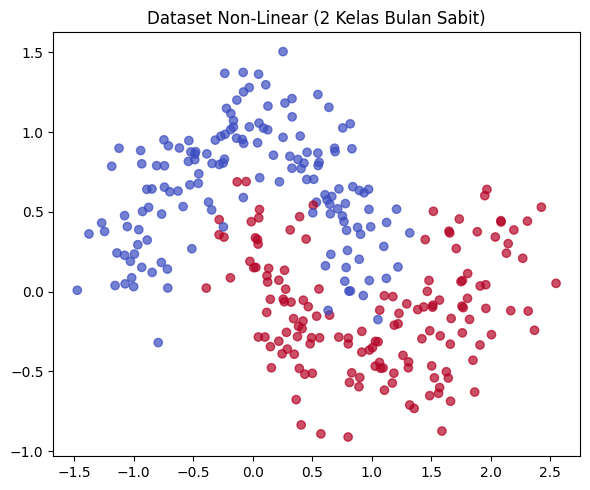

Shape: (300, 2) | Kelas: [0, 1]


In [2]:
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.tight_layout()
plt.show()

print('Shape:', X.shape, '| Kelas:', sorted(set(int(v) for v in y)))


## Langkah 2: Bangun & Latih Neural Network

Arsitektur sederhana: hidden 16 (ReLU) → hidden 8 (ReLU) → output 1 (Sigmoid). ReLU menangani non-linearitas; Sigmoid mengeluarkan probabilitas kelas.


In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Sequential([
    Input(shape=(2,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    X_tr, y_tr, epochs=30, validation_split=0.2, verbose=0
)
print('Pelatihan selesai (30 epoch)')


E0000 00:00:1786930187.813335 1786832 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Pelatihan selesai (30 epoch)


## Langkah 3: Evaluasi & Kurva Belajar


Akurasi pada data uji: 0.900
Loss pada data uji   : 0.334


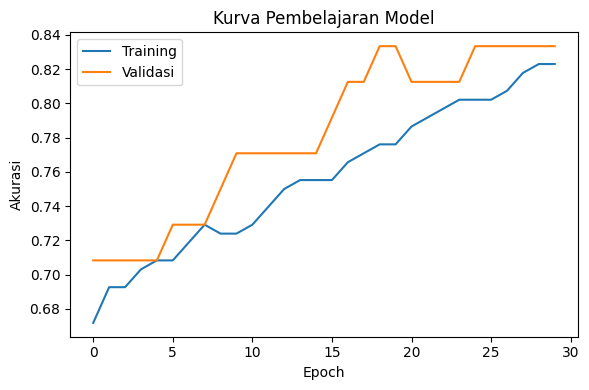

In [4]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')
print(f'Loss pada data uji   : {loss:.3f}')

plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model')
plt.tight_layout()
plt.show()


### Interpretasi kurva belajar

Jika kurva training dan validasi saling mendekat, model belajar dengan wajar. Jika training terus naik sementara validasi turun, itu indikasi overfitting. Dataset `make_moons` kecil dan polanya jelas, jadi 30 epoch biasanya cukup tanpa overfitting parah.


## Langkah 4: Dataset Ulasan Produk

40 ulasan sintetis berbahasa Indonesia, seimbang 20 positif / 20 negatif.


In [5]:
ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Packing rapi dan produk original',
    'Penjual lambat merespons keluhan saya',
    'Bahan adem dipakai, nyaman seharian',
    'Jahitan lepas setelah dua kali cuci',
    'Warna sesuai foto, tidak ada cacat',
    'Ukurannya meleset jauh dari yang dipesan',
    'Pelayanan ramah, proses refund mudah',
    'Barang palsu, kecewa berat',
    'Baterai tahan lama, worth it dibeli',
    'Cepat panas dan bunyi berisik',
    'Instruksi jelas, gampang dirakit sendiri',
    'Komponen kurang, harus beli tambahan',
    'Wanginya enak, tidak menyengat',
    'Bau menyengat dan bikin pusing',
    'Harga murah tapi mutu tetap oke',
    'Mahal tapi hasilnya mengecewakan',
    'Pengiriman lebih cepat dari estimasi',
    'Paket datang penyok dan sobek',
    'Seller jujur soal kondisi barang',
    'Foto iklan menyesatkan pembeli',
    'Suara jernih, bassnya mantap',
    'Audio pecah di volume sedang',
    'Aplikasi ringan dan tidak lemot',
    'Sering force close, tidak bisa dipakai',
    'Garansi dihormati, servisnya cepat',
    'Garansi ditolak tanpa alasan jelas',
    'Desainnya elegan, cocok untuk kado',
    'Tampilan murahan, catnya mudah terkelupas',
    'Stok lengkap, pilihan warnanya banyak',
    'Yang dipesan tidak tersedia tanpa kabar',
    'Manual berbahasa Indonesia, mudah dipahami',
    'Tidak ada panduan, harus tebak sendiri',
    'After sales membantu sampai masalah selesai',
    'Setelah dibayar, chat seller tidak dibalas',
]
label = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

print('Jumlah ulasan:', len(ulasan))
print('Positif:', sum(label), '| Negatif:', len(label) - sum(label))


Jumlah ulasan: 40
Positif: 20 | Negatif: 20


## Langkah 5: Ubah Teks Menjadi TF-IDF

TF-IDF menimbang kata yang khas di suatu ulasan dan meredam kata yang muncul di hampir semua dokumen.


In [6]:
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print('Contoh kosakata:', list(tfidf.get_feature_names_out()[:12]))


Jumlah kata unik: 160
Contoh kosakata: ['ada', 'adem', 'after', 'akan', 'alasan', 'aplikasi', 'audio', 'bagus', 'bahan', 'banget', 'banyak', 'barang']


## Langkah 6: Klasifikasi Sentimen & Uji Kalimat Baru


In [7]:
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42, stratify=label
)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

kalimat_baru = [
    'Pelayanan sangat memuaskan dan ramah',
    'Barang rusak dan pengiriman lama',
]
for kalimat in kalimat_baru:
    pred = model_sentimen.predict(tfidf.transform([kalimat]))[0]
    print(f'{kalimat!r} →', 'Positif' if pred == 1 else 'Negatif')


Akurasi model sentimen: 0.500
'Pelayanan sangat memuaskan dan ramah' → Positif
'Barang rusak dan pengiriman lama' → Negatif


## Kesimpulan

### Apa yang Dipelajari
- Neural network sederhana (Dense + ReLU + Sigmoid) untuk data yang tidak linier
- Kurva belajar training vs validasi sebagai sinyal overfitting
- TF-IDF mengubah teks menjadi vektor numerik; Logistic Regression jadi baseline sentimen yang cepat

### Temuan Utama
- Neural network mencapai akurasi uji **0.900** pada `make_moons` — pola bulan sabit bisa dipisah oleh hidden layer ReLU
- 40 ulasan seimbang (20/20); kosakata TF-IDF 160 kata unik
- Akurasi sentimen di test set 0.500 (hanya 8 sampel uji) — tetapi dua kalimat baru terklasifikasi benar: memuaskan/ramah → Positif, rusak/lama → Negatif

### Keterbatasan
- Dataset teks kecil (40 baris) — akurasi test set mudah melonjak atau anjlok karena n uji hanya 8
- TF-IDF tidak memahami konteks (sinonim, sarkasme, negasi panjang)
- ANN di sini hanya 2 fitur sintetis; belum menyentuh gambar atau teks dengan embedding modern
